# Bimodal Gaussian location model

### Setup

We simulate bimodal data from a two-component Gaussian mixture, which we denote $P_0$ (see below). We define a misspecified unimodal normal-location model in PyMC and sample its predictively oriented posterior with `sample_pro`. Under misspecification, the PrO posterior predictive for $y$ should place mass near both mixture modes (Theorem 1, McLatchie et al., [arXiv:2510.01915](https://arxiv.org/abs/2510.01915)).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import xarray as xr

import pymc_prop as pro


In [2]:
az.style.use("arviz-variat")

## Simulate bimodal data

$$P_0 = 0.4\,\mathcal{N}(-1.5,\,0.7^2) + 0.6\,\mathcal{N}(2.25,\,0.7^2).$$

In [3]:
N = 800
sigma = 0.7
component_means = np.array([-1.5, 2.25])
component_weights = np.array([0.4, 0.6])
SEED = 2026

# draw component labels then observations -- reproducible rng
rng = np.random.default_rng(SEED)
components = rng.choice(len(component_means), size=N, p=component_weights)
y = rng.normal(loc=component_means[components], scale=sigma)

# plotting limits around component means
xlim = (component_means.min() - 3 * sigma, component_means.max() + 3 * sigma)

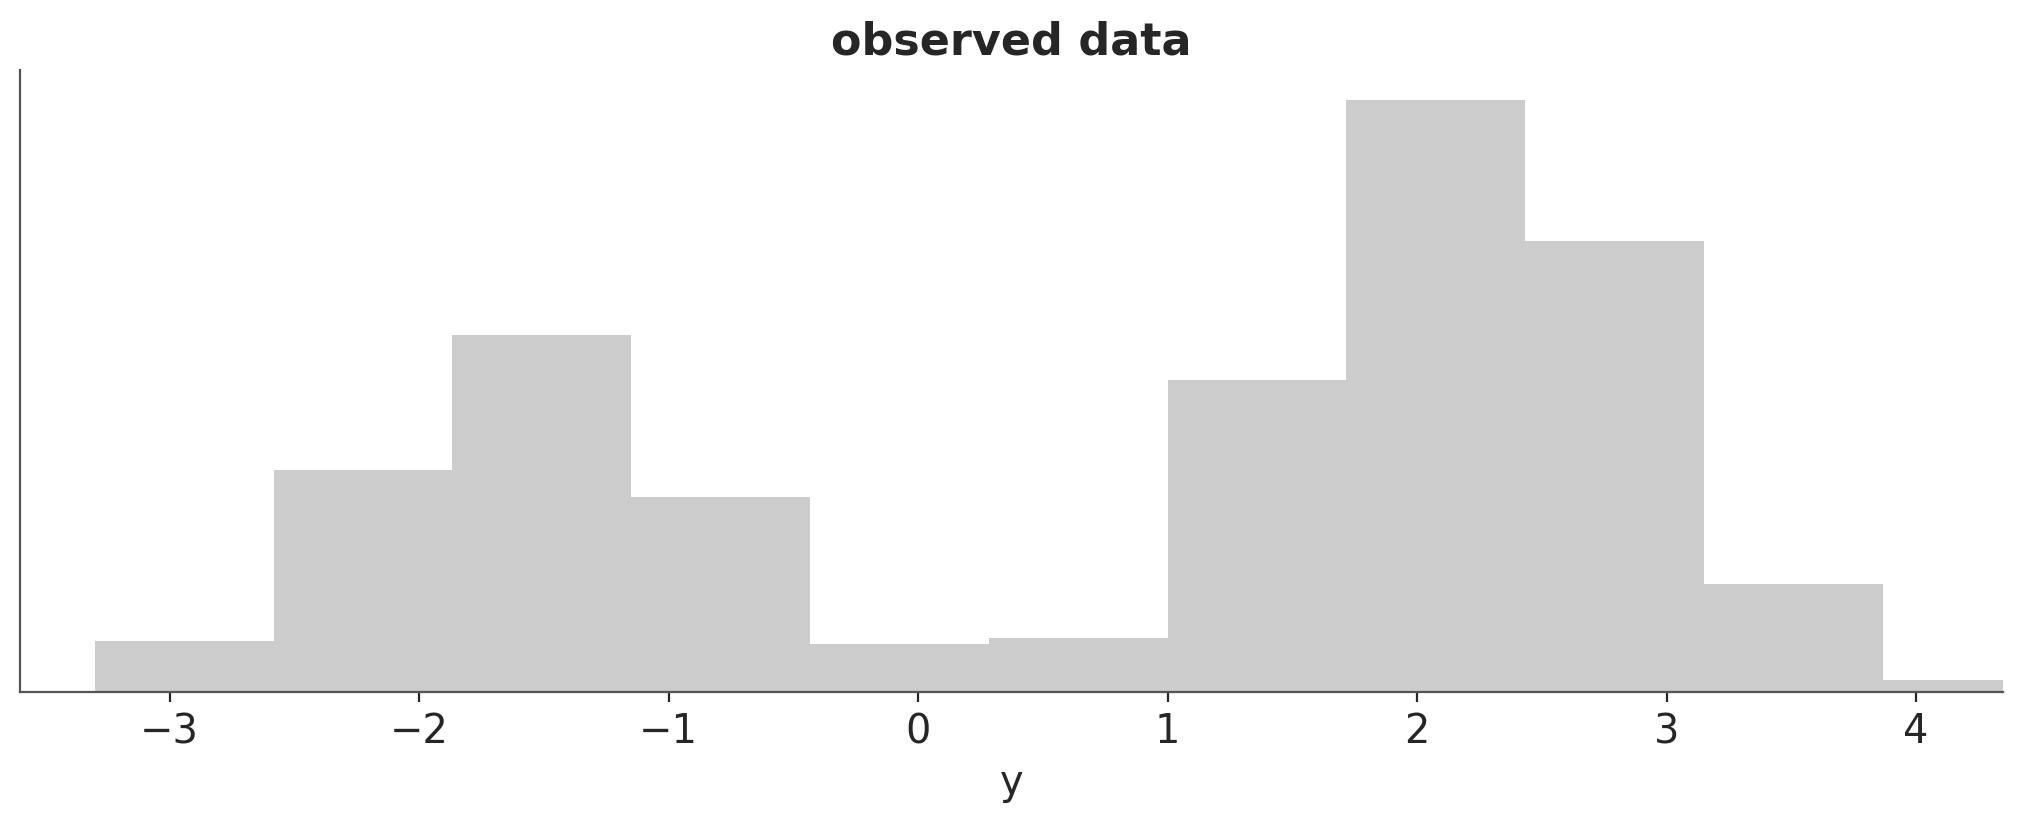

In [4]:
# histogram of the simulated data (verify bimodality)
_, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    y,
    bins="auto",
    color="0.8",
    edgecolor=None,
)
ax.set(title="observed data", xlabel="y", xlim=xlim, yticks=[]);


## PyMC model (misspecified unimodal likelihood)

We place a prior $\mathcal{N}(0, 1)$ on $\mu$ and define
$y_i \mid \mu \sim \mathcal{N}(\mu, \sigma^2)$ with known $\sigma$ (same as in $P_0$).

In [5]:
# misspecified normal-location model: prior N(0,1) on mu; known sigma
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)

### Run the sampler

Sampling uses a particle-discretised Wasserstein gradient flow on $N = 800$ observations. We retain every step (`tune=0`) so we can plot full particle trajectories.

40 particles, 2500 steps, step size `8e-4`, and learning rate $\lambda_n = 1$ (default). Below we plot trajectories, then a posterior predictive check in $y$-space.


In [6]:
dt = pro.sample_pro(
    model=model,
    n_particles=40,
    n_steps=2500,
    step_size=8e-4,
    tune=0,
    random_seed=SEED,
)


## ArviZ DataTree output

As other inference methods in the PyMC ecosystem, `pmp.sample_pro` returns a [DataTree](https://python.arviz.org/projects/base/en/latest/tutorial/WorkingWithDataTree.html). The structure is similar to MCMC output, with `draw` and `chain` coordinates. Here `draw` is a retained index, `step` stores the simulation step number, and `chain` indexes the particle. Do not run MCMC diagnostics such as `az.rhat` or `az.ess` over particles; they are ensemble trajectories, not independent posterior draws. `sample_stats` includes heuristic `mean_log_score` and `se_log_score` traces along the flow.

In [7]:
dt

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (draw: 2500, chain: 40)
│       Coordinates:
│         * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│           step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│         * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
│       Data variables:
│           mu       (draw, chain) float64 800kB 0.01728 1.24 -2.068 ... 2.067 2.46
│       Attributes:
│           created_at:                 2026-07-01T07:56:58.293348+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 800)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
│       Data variables:
│           y        (y_dim_0) float64 6kB -1.696 2.014 2.631 ... 1.25 -0.3845 -2.138
│       Attributes:
│           created_at:                 2026-07-01T07:56:58.297480+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /log_likelihood
│       Dimensions:  (draw: 2500, chain: 40, y_dim_0: 800)
│       Coordinates:
│         * draw     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│           step     (draw) int64 20kB 0 1 2 3 4 5 6 ... 2494 2495 2496 2497 2498 2499
│         * chain    (chain) int64 320B 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 39
│         * y_dim_0  (y_dim_0) int64 6kB 0 1 2 3 4 5 6 7 ... 793 794 795 796 797 798 799
│       Data variables:
│           y        (draw, chain, y_dim_0) float64 640MB -3.558 -4.63 ... -8.82 -22.14
│       Attributes:
│           created_at:                 2026-07-01T07:56:58.293348+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
└── Group: /sample_stats
        Dimensions:          (draw: 2500, chain: 40)
        Coordinates:
          * draw             (draw) int64 20kB 0 1 2 3 4 5 ... 2495 2496 2497 2498 2499
            step             (draw) int64 20kB 0 1 2 3 4 5 ... 2495 2496 2497 2498 2499
          * chain            (chain) int64 320B 0 1 2 3 4 5 6 7 ... 33 34 35 36 37 38 39
        Data variables:
            particle_spread  (draw, chain) float64 800kB 1.841 1.841 ... 1.841 1.841
            learning_rate    (draw, chain) float64 800kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
            mu_spread        (draw, chain) float64 800kB 1.841 1.841 ... 1.841 1.841
            mean_log_score   (draw, chain) float64 800kB -6.439e+03 ... -6.262e+03
            se_log_score     (draw, chain) float64 800kB 452.9 452.9 ... 252.7 252.7
        Attributes:
            created_at:                 2026-07-01T07:56:58.293348+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.0
            creation_library_language:  Python
            sample_dims:                ['draw', 'chain']
            inference_library:          pymc
            inference_library_version:  6.0.0

## Particle trajectories

Each line is one particle $\mu_t^{(j)}$ in **parameter space**. Under misspecification, trajectories often split across values that reflect both mixture modes. Do not overlay observed $y$ or data-generating quantities on this plot: only the posterior predictive and the posterior live on the same space in general; here $\mu$ and $y$ both lie on $\mathbb{R}$, which is coincidental for this toy model.


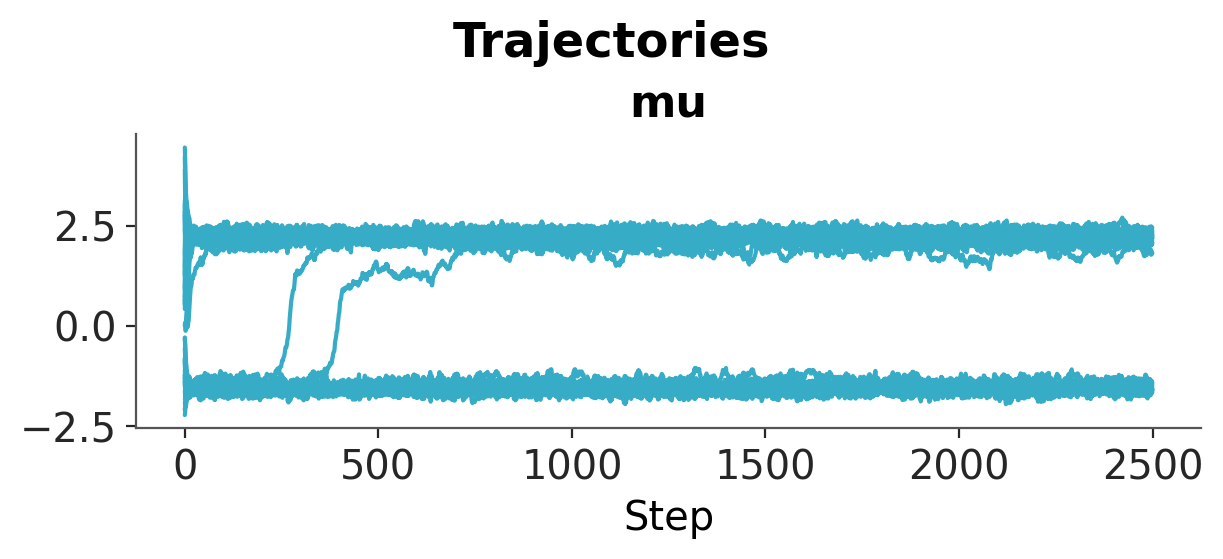

In [8]:
pc = az.plot_trace(
    dt,
    var_names=["mu"],
    aes={"color": False, "overlay": ["chain"]},
    visuals={"trace": {"color": "C0", "xname": "step"}},
)
pc.add_title("Trajectories")


## Posterior predictive check

Compare **observed** $y$ to the **posterior predictive** for $y$ (replicates drawn from $p(y \mid \text{data})$ by sampling $\mu^{(j)}$ from the particle cloud). The PPC already marginalizes over the posterior; we do not need an extra "marginal" qualifier. For the PPC we manually drop the first 100 retained draws and keep every 10th draw. The trajectory plot above used `tune=0`; here we subsample in post-processing. (To retain fewer points at sampling time, lower `n_steps` or subsample the returned DataTree.)

In [9]:
dt_bi = dt.filter(lambda node: "draw" in node.dims).sel(draw=slice(100, None, 10))

In [10]:
num_samples = 50
n_obs = dt.observed_data["y"].size
rng = np.random.default_rng(221)

draw_indices = rng.choice(dt_bi.posterior["mu"].draw, size=num_samples, replace=False)
posterior = dt_bi.posterior["mu"].sel(draw=draw_indices)

chain_indices = rng.integers(0, posterior.sizes["chain"], size=(num_samples, n_obs))
mu_expanded = np.take_along_axis(posterior.values, chain_indices, axis=1)

y_pp_data = rng.normal(loc=mu_expanded, scale=sigma)
y_pp = xr.Dataset({"y": (["draws", "y_dim_0"], y_pp_data)})
dt["posterior_predictive"] = y_pp


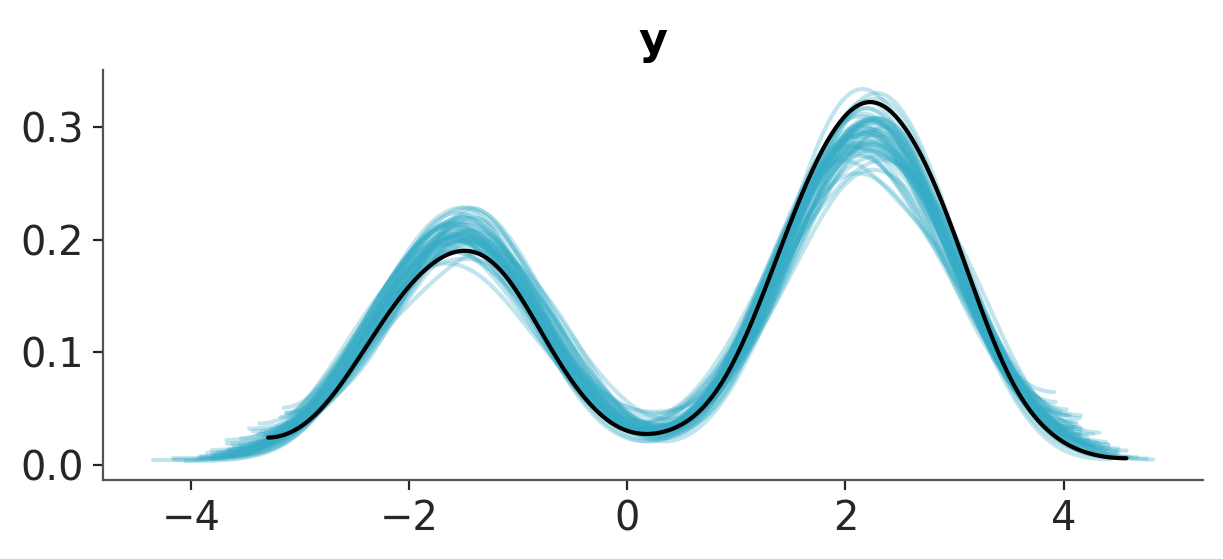

In [11]:
az.plot_ppc_dist(dt, sample_dims=["draws"]);
